# Notebook 3 - Brain Age Gap, Modelos y Estadistica
**Prerequisito:** Notebooks 1 y 2 ejecutados.

## Modelos implementados
| Modelo | Features | Referencia |
|--------|----------|-----------|
| beta-VAE + XGBoost | FC(6670)->Z(64)+T1w(116) | Thesis - principal |
| FC raw + XGBoost | FC(6670) | Thesis - baseline |
| Topo + XGBoost | 6 metricas | Este trabajo |
| Topo + Ridge | 6 metricas | Thesis - comparacion |
| Topo + SVR | 6 metricas | Thesis - comparacion |
| Topo + MLP | 6 metricas | Nuevo - TensorFlow |
| beta-VAE + T1w + MLP | Z(64)+T1w(116) | Nuevo - TensorFlow |

**Split:** 90/10 estratificado sex x diagnostico (igual que Thesis).  
**Validacion:** 5-fold CV sobre trainval.  
**Entrenamiento BAG:** solo controles sanos (CN).

In [1]:
import sys, os
sys.path.insert(0, "Thesis/Code")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
import warnings
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import KFold, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from src.vae_train import train_vae_final, load_vae_from_dir
from src.splits import make_holdout_split
from src.metrics import regression_metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
os.makedirs("figs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TOPO = ["local_efficiency", "global_efficiency", "clustering_coeff",
        "fp_local_efficiency", "fp_betweenness", "fp_degree"]
COLORS = {"CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26"}
print("Setup completo.")

Setup completo.


## 1. Cargar datos

In [2]:
graph_df = pd.read_csv("outputs/graph_metrics_table.csv")
eligible = pd.read_csv("outputs/eligible_fc_subjects.csv")
graph_df = graph_df.merge(eligible[["MRI_ID", "mmse_total"]], on="MRI_ID", how="left")

vbm_raw  = pd.read_csv("outputs/vbm_features.csv")
t1w_cols = [c for c in vbm_raw.columns
            if c.startswith("gm_") and c not in ["gm_total", "gm_fp_mean"]]
graph_df = graph_df.merge(
    vbm_raw[["MRI_ID"] + t1w_cols + ["gm_total", "gm_fp_mean"]],
    on="MRI_ID", how="left"
)

df = graph_df.dropna(subset=TOPO + ["Age"]).copy().reset_index(drop=True)
print(f"Sujetos: {len(df)}")
print(f"Diagnosticos: {df['diagnosis'].value_counts().to_dict()}")
df[TOPO].describe().round(4)

Sujetos: 1327
Diagnosticos: {'CN': 555, 'AD': 468, 'FTD': 304}


,local_efficiency,global_efficiency,clustering_coeff,fp_local_efficiency,fp_betweenness,fp_degree
count,1327.0000,1327.0000,1327.0000,1327.0000,1327.0000,1327.0000
mean,0.8564,0.7542,0.7186,0.8553,0.0052,0.5754
std,0.0548,0.0817,0.1033,0.0569,0.0022,0.1830
min,0.4624,0.4976,0.2527,0.4697,0.0003,0.1224
25%,0.8192,0.6917,0.6445,0.8145,0.0037,0.4283
50%,0.8540,0.7446,0.7119,0.8518,0.0051,0.5565
75%,0.8931,0.8093,0.7897,0.8962,0.0066,0.7152
max,0.9842,0.9712,0.9684,0.9898,0.0142,0.9857


In [3]:
FC_DIR = Path("outputs/fc_matrices")
triu_i, triu_j = np.triu_indices(116, k=1)
fc_vectors = {}
for _, row in df.iterrows():
    p = FC_DIR / f"{row['MRI_ID']}_fc_z.npy"
    if p.exists():
        fc_vectors[row["MRI_ID"]] = np.load(p)[triu_i, triu_j].astype(np.float32)
print(f"Vectores FC: {len(fc_vectors)} (6670 features c/u)")
print(f"T1w features: {len(t1w_cols)} regiones AAL")

Vectores FC: 1327 (6670 features c/u)
T1w features: 116 regiones AAL


## 2. Split de datos (replicando Thesis)

90% trainval / 10% test, estratificado por sexo x diagnostico. Entrenamiento solo en CN.

In [8]:
split    = make_holdout_split(
    df.rename(columns={"MRI_ID": "record_id"}),  # fix del error anterior
    seed=SEED,
    test_size=0.10,
)
tv_ids   = set(split["trainval_ids"])
test_ids = set(split["test_ids"])

df_tv    = df[df["MRI_ID"].isin(tv_ids)].copy().reset_index(drop=True)
df_test  = df[df["MRI_ID"].isin(test_ids)].copy().reset_index(drop=True)
df_cn_tv = df_tv[df_tv["diagnosis"] == "CN"].copy().reset_index(drop=True)

print(f"Trainval: {len(df_tv)} | CN trainval: {len(df_cn_tv)} | Test: {len(df_test)}")

Trainval: 1194 | CN trainval: 499 | Test: 133


## 3. Helpers de evaluacion

In [9]:
def cv5(X, y, fn):
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    ms = []
    for tr, va in kf.split(X):
        m = fn(); m.fit(X[tr], y[tr])
        ms.append(regression_metrics(y[va], m.predict(X[va])))
    return {k: {"mean": float(np.mean([f[k] for f in ms])),
               "std":  float(np.std([f[k] for f in ms]))}
            for k in ms[0]}

def pprint(name, cv):
    print(f"{name:45s}  MAE={cv['MAE']['mean']:.2f}+/-{cv['MAE']['std']:.2f}"
          f"  R2={cv['R2']['mean']:.3f}  r={cv['Pearson']['mean']:.3f}")

print("Helpers listos.")

Helpers listos.


## 4. Comparacion de modelos

### 4.1 Preparar features CN

In [10]:
df_cn  = df_cn_tv[df_cn_tv[t1w_cols[0]].notna()].copy().reset_index(drop=True)
X_topo = df_cn[TOPO].values.astype(np.float32)
X_t1w  = df_cn[t1w_cols].fillna(0).values.astype(np.float32)
y_cn   = df_cn["Age"].values.astype(np.float32)

has_fc   = [sid in fc_vectors for sid in df_cn["MRI_ID"]]
X_fc     = np.array([fc_vectors[s] for s in df_cn["MRI_ID"] if s in fc_vectors], dtype=np.float32)
y_cn_fc  = y_cn[has_fc]
X_t1w_fc = X_t1w[has_fc]

print(f"CN con T1w: {len(df_cn)} | con FC: {sum(has_fc)}")
print(f"X_topo: {X_topo.shape} | X_fc: {X_fc.shape}")
results = {}

CN con T1w: 472 | con FC: 472
X_topo: (472, 6) | X_fc: (472, 6670)


### 4.2 Modelos sklearn

In [11]:
XGB_P = dict(n_estimators=2103, max_depth=6, learning_rate=0.0110,
             subsample=0.5021, colsample_bytree=0.9506,
             reg_alpha=0.00136, reg_lambda=7.084, min_child_weight=1.142,
             gamma=0.675, tree_method="hist", eval_metric="mae",
             random_state=SEED, verbosity=0)

make_xgb = lambda: Pipeline([("sc", StandardScaler()), ("m", XGBRegressor(**XGB_P))])
make_rdg = lambda: Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=267.7))])
make_svr = lambda: Pipeline([("sc", StandardScaler()), ("m", SVR(kernel="rbf", C=10.0, epsilon=0.5))])

for name, X, y, fn in [
    ("Topo + XGBoost",           X_topo, y_cn,    make_xgb),
    ("Topo + Ridge  (Thesis)",   X_topo, y_cn,    make_rdg),
    ("Topo + SVR    (Thesis)",   X_topo, y_cn,    make_svr),
    ("FC raw + XGBoost (Thesis)", X_fc,  y_cn_fc, make_xgb),
]:
    results[name] = cv5(X, y, fn)
    pprint(name, results[name])

Topo + XGBoost                                 MAE=9.87+/-0.56  R2=-0.284  r=0.036
Topo + Ridge  (Thesis)                         MAE=8.78+/-0.69  R2=-0.008  r=0.120
Topo + SVR    (Thesis)                         MAE=8.77+/-0.67  R2=-0.042  r=0.080
FC raw + XGBoost (Thesis)                      MAE=8.07+/-0.67  R2=0.162  r=0.441


### 4.3 beta-VAE + XGBoost / Ridge / SVR (Thesis)

In [14]:
VAE_P = dict(hidden_dims=[512], latent_dim=64, activation="elu",
             norm_kind="layer", beta_target=0.0567, warmup_ep=73,
             l2_reg=1e-4, drop_rate=0.0369, recon_kind="mae",
             lr=0.001892, clipnorm=1.0, max_epochs=150, batch_size=64)

VAE_DIR = Path("outputs/models")
if (VAE_DIR / "vae.weights.h5").exists():
    print("Cargando VAE desde disco...")
    vae = load_vae_from_dir(VAE_DIR)
else:
    print(f"Entrenando beta-VAE sobre {len(X_fc)} CN ({X_fc.shape[1]} features)...")
    vae, _ = train_vae_final(
        X_fc,
        out_dir=VAE_DIR,
        **{k: v for k, v in VAE_P.items() if k not in ("seed", "max_epochs")},
        epochs=VAE_P["max_epochs"],
        seed=SEED,
    )
    print("VAE guardado.")

mu, _, _ = vae.encoder.predict(X_fc, verbose=0)
X_vae_t1w = np.hstack([mu, X_t1w_fc])
print(f"Embeddings mu: {mu.shape} | X_vae_t1w: {X_vae_t1w.shape}")

Entrenando beta-VAE sobre 472 CN (6670 features)...

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - kl_loss: 312.9186 - loss: 2201.2463 - recon_loss: 2201.2463 - learning_rate: 0.0019
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - kl_loss: 674.2087 - loss: 1481.3815 - recon_loss: 1480.8577 - learning_rate: 0.0019
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - kl_loss: 777.8773 - loss: 1319.5968 - recon_loss: 1318.3883 - learning_rate: 0.0019
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - kl_loss: 885.2545 - loss: 1278.2572 - recon_loss: 1276.1945 - learning_rate: 0.0019
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - kl_loss: 851.3708 - loss: 1274.4613 - recon_loss: 1271.8163 - learning_rate: 0.0019
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - kl_loss: 822.4761 - loss: 1227.7063 - recon_loss: 1224.5122 - learning_rate: 0.0019
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - kl_loss: 738.4099 - loss: 1175.0634 - recon_loss: 1171.6222 - learning_r

In [15]:
for name, fn in [
    ("beta-VAE + T1w + XGBoost (Thesis)", make_xgb),
    ("beta-VAE + T1w + Ridge   (Thesis)", make_rdg),
    ("beta-VAE + T1w + SVR     (Thesis)", make_svr),
]:
    results[name] = cv5(X_vae_t1w, y_cn_fc, fn)
    pprint(name, results[name])

beta-VAE + T1w + XGBoost (Thesis)              MAE=7.04+/-0.54  R2=0.368  r=0.621
beta-VAE + T1w + Ridge   (Thesis)              MAE=7.05+/-0.33  R2=0.380  r=0.638
beta-VAE + T1w + SVR     (Thesis)              MAE=7.15+/-0.35  R2=0.337  r=0.614


### 4.4 MLP (TensorFlow) - nuevo

In [16]:
def build_mlp(input_dim, hidden=None, dropout=0.3, lr=1e-3, l2=1e-4):
    if hidden is None: hidden = [256, 128, 64]
    reg = keras.regularizers.l2(l2)
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for u in hidden:
        x = layers.Dense(u, activation="elu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="mae")
    return m

def cv5_mlp(X, y, hidden, epochs=300, bs=32):
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    sc = StandardScaler(); ms = []
    cbs = [EarlyStopping(monitor="val_loss", patience=20,
                         restore_best_weights=True, verbose=0),
           ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                             patience=10, min_lr=1e-5, verbose=0)]
    for fold, (tr, va) in enumerate(kf.split(X)):
        tf.keras.backend.clear_session()
        Xtr = sc.fit_transform(X[tr]); Xva = sc.transform(X[va])
        mlp = build_mlp(X.shape[1], hidden=hidden)
        mlp.fit(Xtr, y[tr], validation_data=(Xva, y[va]),
                epochs=epochs, batch_size=bs, callbacks=cbs, verbose=0)
        pred = mlp.predict(Xva, verbose=0).flatten()
        ms.append(regression_metrics(y[va], pred))
        print(f"  fold {fold+1}: MAE={ms[-1]['MAE']:.2f}")
    return {k: {"mean": float(np.mean([f[k] for f in ms])),
               "std":  float(np.std([f[k] for f in ms]))}
            for k in ms[0]}

print("MLP definido.")

MLP definido.


In [17]:
print("Topo + MLP...")
results["Topo + MLP (TF)"] = cv5_mlp(X_topo, y_cn, hidden=[128, 64, 32])
pprint("Topo + MLP (TF)", results["Topo + MLP (TF)"])

Topo + MLP...
  fold 1: MAE=9.03
  fold 2: MAE=9.68
  fold 3: MAE=8.29
  fold 4: MAE=8.95
  fold 5: MAE=7.66
Topo + MLP (TF)                                MAE=8.72+/-0.69  R2=-0.001  r=0.124


In [18]:
print("beta-VAE + T1w + MLP...")
results["beta-VAE + T1w + MLP (TF)"] = cv5_mlp(X_vae_t1w, y_cn_fc, hidden=[256, 128, 64])
pprint("beta-VAE + T1w + MLP (TF)", results["beta-VAE + T1w + MLP (TF)"])

beta-VAE + T1w + MLP...
  fold 1: MAE=7.36
  fold 2: MAE=6.54
  fold 3: MAE=6.22
  fold 4: MAE=7.43
  fold 5: MAE=6.52
beta-VAE + T1w + MLP (TF)                      MAE=6.81+/-0.49  R2=0.358  r=0.633


### 4.5 Tabla y grafico comparativo

In [19]:
rows = [{"Modelo": n,
         "MAE":    f"{cv['MAE']['mean']:.2f} +/- {cv['MAE']['std']:.2f}",
         "R2":     f"{cv['R2']['mean']:.3f} +/- {cv['R2']['std']:.3f}",
         "Pearson":f"{cv['Pearson']['mean']:.3f}",
         "_mae":   cv["MAE"]["mean"]}
        for n, cv in results.items()]

cmp_df = pd.DataFrame(rows).sort_values("_mae")
print("=== COMPARACION DE MODELOS (5-fold CV, CN) ===")
print(cmp_df.drop("_mae", axis=1).to_string(index=False))
cmp_df.drop("_mae", axis=1).to_csv("outputs/model_comparison.csv", index=False)

=== COMPARACION DE MODELOS (5-fold CV, CN) ===
                           Modelo           MAE               R2 Pearson
        beta-VAE + T1w + MLP (TF) 6.81 +/- 0.49  0.358 +/- 0.125   0.633
beta-VAE + T1w + XGBoost (Thesis) 7.04 +/- 0.54  0.368 +/- 0.101   0.621
beta-VAE + T1w + Ridge   (Thesis) 7.05 +/- 0.33  0.380 +/- 0.074   0.638
beta-VAE + T1w + SVR     (Thesis) 7.15 +/- 0.35  0.337 +/- 0.051   0.614
        FC raw + XGBoost (Thesis) 8.07 +/- 0.67  0.162 +/- 0.060   0.441
                  Topo + MLP (TF) 8.72 +/- 0.69 -0.001 +/- 0.044   0.124
           Topo + SVR    (Thesis) 8.77 +/- 0.67 -0.042 +/- 0.060   0.080
           Topo + Ridge  (Thesis) 8.78 +/- 0.69 -0.008 +/- 0.015   0.120
                   Topo + XGBoost 9.87 +/- 0.56 -0.284 +/- 0.157   0.036


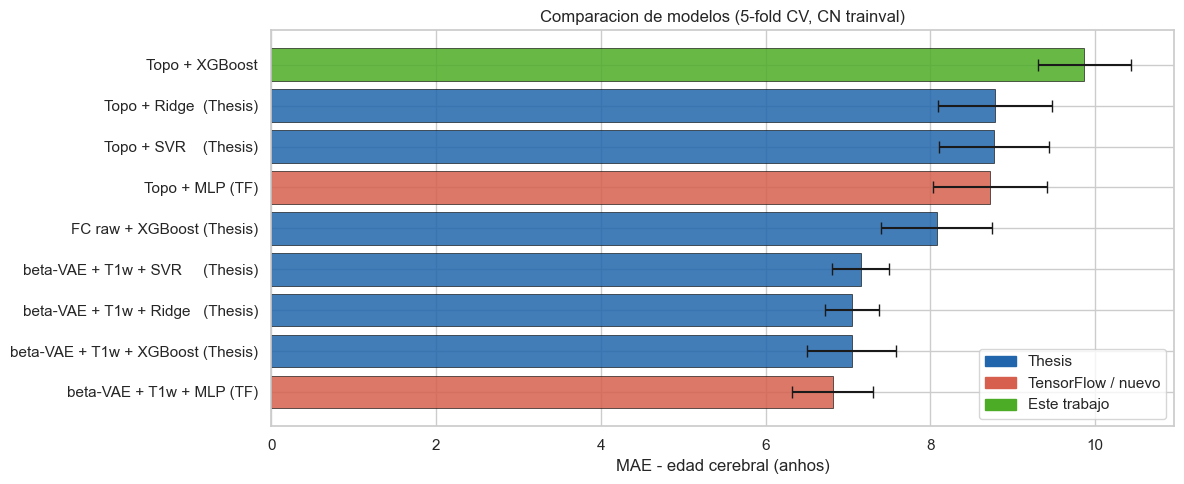

In [20]:
names = list(results.keys())
mae_m = [results[n]["MAE"]["mean"] for n in names]
mae_s = [results[n]["MAE"]["std"]  for n in names]
cols  = ["#d6604d" if "TF" in n else ("#2166ac" if "Thesis" in n else "#4dac26")
         for n in names]
fig, ax = plt.subplots(figsize=(12, 5))
idx = np.argsort(mae_m)
ax.barh([names[i] for i in idx], [mae_m[i] for i in idx],
        xerr=[mae_s[i] for i in idx],
        color=[cols[i] for i in idx], capsize=4, alpha=0.85, edgecolor="black", lw=0.5)
ax.set_xlabel("MAE - edad cerebral (anhos)")
ax.set_title("Comparacion de modelos (5-fold CV, CN trainval)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2166ac", label="Thesis"),
                   Patch(color="#d6604d", label="TensorFlow / nuevo"),
                   Patch(color="#4dac26", label="Este trabajo")])
plt.tight_layout()
plt.savefig("figs/03_model_comparison.png", dpi=150)
plt.show()

## 5. Modelo final y BAG

In [27]:
# CN trainval: TOPO completo Y sitio conocido (requerido para LOSO)
df_cn_topo = df_cn_tv.dropna(subset=TOPO + ["site"]).copy().reset_index(drop=True)
X_cn_all   = df_cn_topo[TOPO].values.astype(np.float32)
y_cn_all   = df_cn_topo["Age"].values.astype(np.float32)

pipe_final = make_xgb()
pipe_final.fit(X_cn_all, y_cn_all)

X_all    = df[TOPO].fillna(df[TOPO].median()).values.astype(np.float32)
y_all    = df["Age"].values.astype(np.float32)
pred_all = pipe_final.predict(X_all)

print(f"Entrenado en {len(X_cn_all)} CN (con site). Predicciones para {len(df)} sujetos.")

Entrenado en 368 CN (con site). Predicciones para 1327 sujetos.


## 6. Correccion del sesgo de regresion a la media

Igual que Thesis paso 9: se regresiona el BAG crudo sobre la edad en CN y se corrige.

In [28]:
logo       = LeaveOneGroupOut()
sites_cn   = df_cn_topo["site"].values   # ya sin NaN
pred_cv_cn = np.zeros(len(X_cn_all))

for tr, te in logo.split(X_cn_all, y_cn_all, groups=sites_cn):
    p = make_xgb()
    p.fit(X_cn_all[tr], y_cn_all[tr])
    pred_cv_cn[te] = p.predict(X_cn_all[te])

r2_cv  = r2_score(y_cn_all, pred_cv_cn)
mae_cv = mean_absolute_error(y_cn_all, pred_cv_cn)
print(f"LOSO-CV CN: R2={r2_cv:.3f} | MAE={mae_cv:.2f} años")

bag_raw_cn = pred_cv_cn - y_cn_all
slope, intercept, r_b, p_b, _ = stats.linregress(y_cn_all, bag_raw_cn)
print(f"Correlación BAG~edad CN: r={r_b:.3f}, p={p_b:.4f}")

df["predicted_age"] = pred_all
df["BAG_raw"]       = pred_all - y_all
df["BAG"]           = df["BAG_raw"] - (slope * df["Age"] + intercept)
df["BAG_group"]     = np.where(df["BAG"] > 0, "BAG+", "BAG-")

print("\nBAG por diagnóstico:")
print(df.groupby("diagnosis")["BAG"].agg(["mean", "std", "count"]).round(2))

LOSO-CV CN: R2=-0.579 | MAE=11.73 años
Correlación BAG~edad CN: r=-0.881, p=0.0000

BAG por diagnóstico:
           mean   std  count
diagnosis                   
AD         0.74  6.74    468
CN         0.96  9.51    555
FTD        1.05  5.90    304


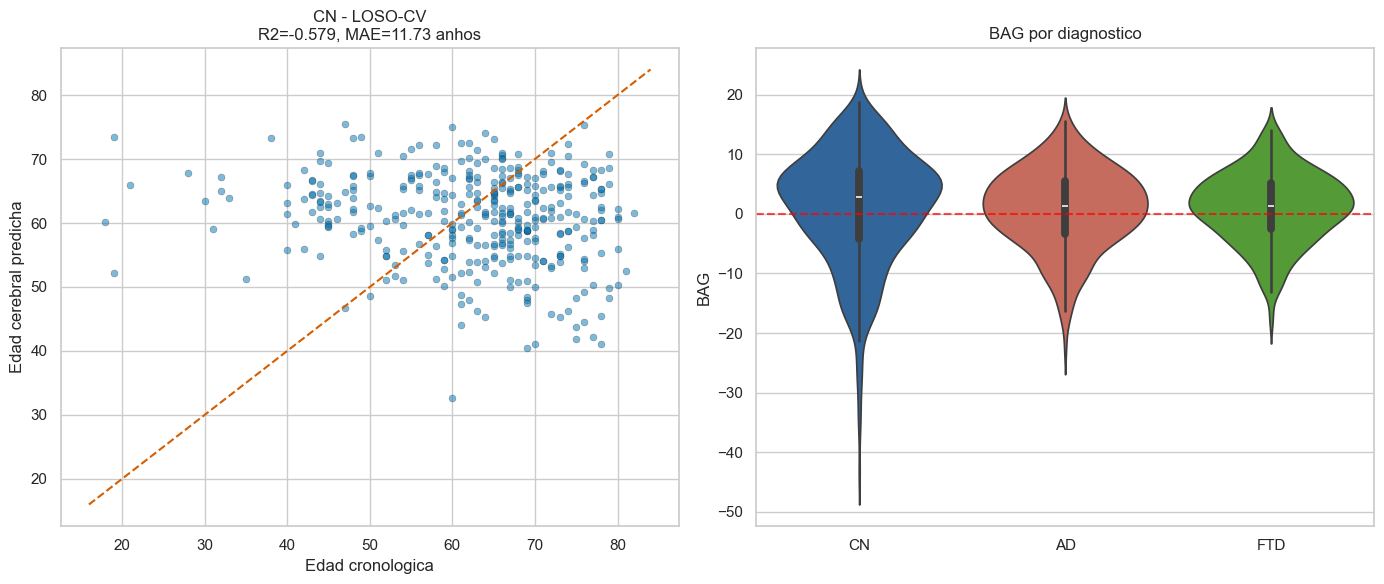

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.scatter(y_cn_all, pred_cv_cn, alpha=0.5, s=25, edgecolors="k", lw=0.3)
lims = [y_cn_all.min()-2, y_cn_all.max()+2]
ax.plot(lims, lims, "r--")
ax.set_xlabel("Edad cronologica"); ax.set_ylabel("Edad cerebral predicha")
ax.set_title(f"CN - LOSO-CV\nR2={r2_cv:.3f}, MAE={mae_cv:.2f} anhos")
ax = axes[1]
sns.violinplot(data=df[df.diagnosis.isin(["CN","AD","FTD"])],
               x="diagnosis", y="BAG", order=["CN","AD","FTD"],
               palette=COLORS, inner="box", ax=ax)
ax.axhline(0, color="red", ls="--", alpha=0.7)
ax.set_title("BAG por diagnostico"); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figs/03_brain_age_prediction_CN.png", dpi=150)
plt.show()

## 7. Comparacion BAG+ vs BAG-

In [31]:
def _pg_val(r, *candidates):
    """Toma la primera columna que exista (compat pingouin <0.6 y >=0.6)."""
    for c in candidates:
        if c in r.columns:
            return r[c].values[0]
    raise KeyError(f"Ninguna de {candidates} en {list(r.columns)}")

def compare_groups(df, metrics, g1="BAG+", g2="BAG-", col="BAG_group"):
    rows = []
    for m in metrics:
        pos = df.loc[df[col] == g1, m].dropna()
        neg = df.loc[df[col] == g2, m].dropna()
        if len(pos) < 3 or len(neg) < 3:
            continue
        if pos.var() < 1e-12 and neg.var() < 1e-12:
            continue
        if pg.normality(pos).iloc[0]["normal"] and pg.normality(neg).iloc[0]["normal"]:
            r = pg.ttest(pos, neg)
            stat = _pg_val(r, "T")
            test = "t-test"
        else:
            r = pg.mwu(pos, neg)
            stat = _pg_val(r, "U_val", "U-val")
            test = "MWU"
        rows.append({
            "metric": m,
            "test": test,
            "stat": round(stat, 3),
            "p_val": _pg_val(r, "p_val", "p-val"),
            "mean_pos": round(pos.mean(), 4),
            "mean_neg": round(neg.mean(), 4),
        })
    out = pd.DataFrame(rows)
    if len(out):
        _, out["p_fdr"], _, _ = multipletests(out["p_val"], method="fdr_bh")
    return out

bag_cmp = compare_groups(df, TOPO)
print(bag_cmp.round(4).to_string())

                metric test      stat  p_val  mean_pos  mean_neg  p_fdr
0     local_efficiency  MWU  283753.0    0.0    0.8683    0.8390    0.0
1    global_efficiency  MWU  277497.5    0.0    0.7717    0.7285    0.0
2     clustering_coeff  MWU  282792.0    0.0    0.7420    0.6845    0.0
3  fp_local_efficiency  MWU  276790.0    0.0    0.8667    0.8387    0.0
4       fp_betweenness  MWU  165183.0    0.0    0.0049    0.0056    0.0
5            fp_degree  MWU  276448.5    0.0    0.6147    0.5181    0.0


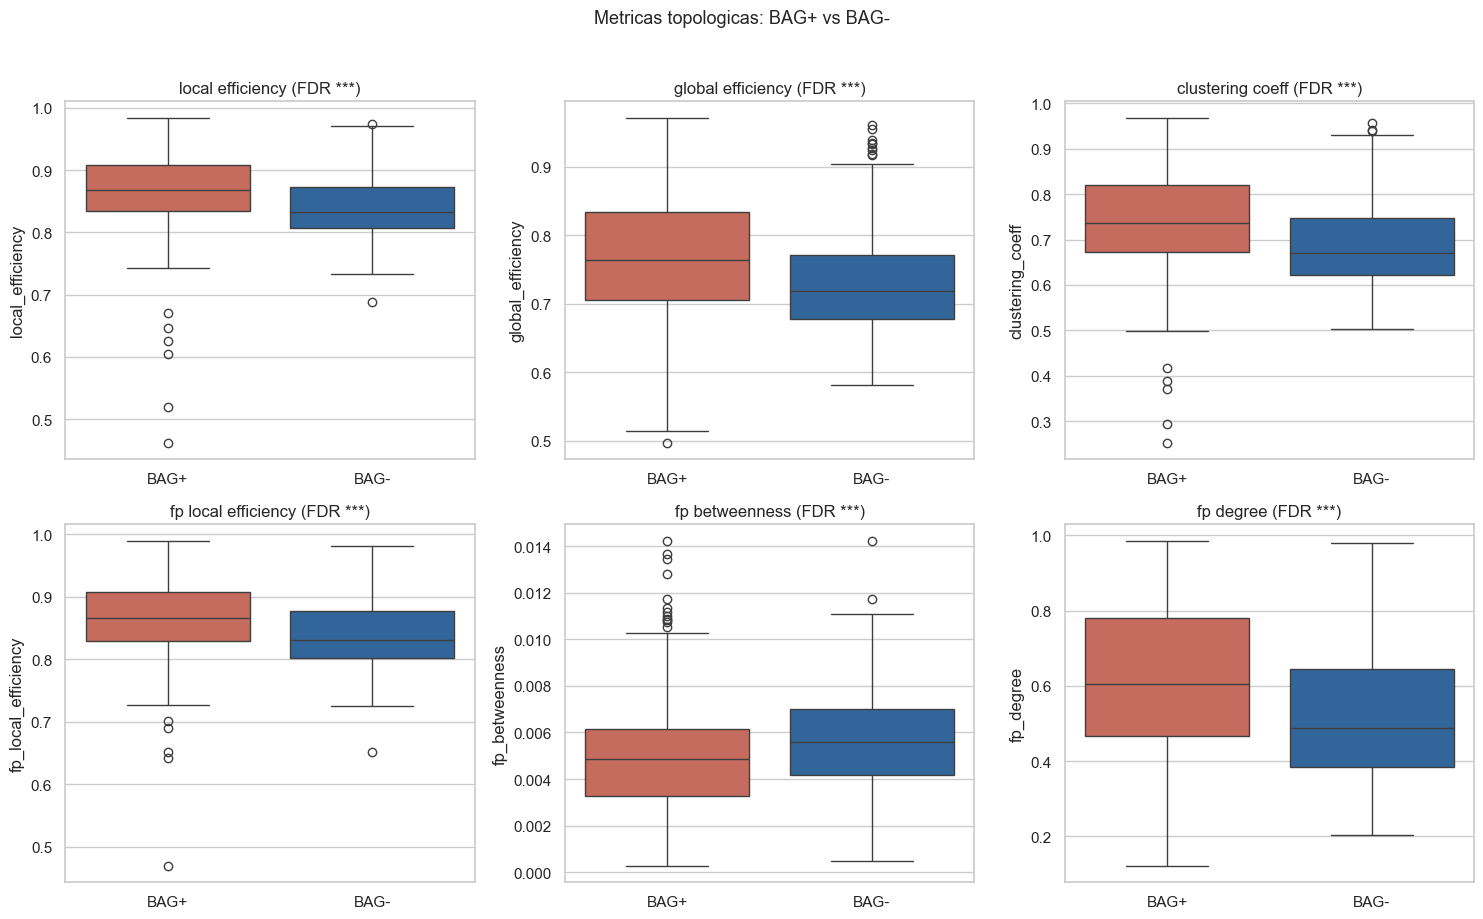

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m in zip(axes.flatten(), TOPO):
    sns.boxplot(data=df, x="BAG_group", y=m,
                palette={"BAG+":"#d6604d","BAG-":"#2166ac"}, ax=ax)
    row = bag_cmp[bag_cmp.metric==m].iloc[0]
    sig = "***" if row.p_fdr<0.001 else ("**" if row.p_fdr<0.01 else
          ("*" if row.p_fdr<0.05 else "ns"))
    ax.set_title(f"{m.replace(chr(95),chr(32))} (FDR {sig})")
    ax.set_xlabel("")
plt.suptitle("Metricas topologicas: BAG+ vs BAG-", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figs/03_topology_BAG_groups.png", dpi=150)
plt.show()

## 8. Regresion multiple: topologia ~ BAG + covariables

In [33]:
df_reg = df.dropna(subset=TOPO + ["BAG", "Age", "years_education"])
reg_rows = []
for m in TOPO:
    try:
        mod = smf.ols(
            f"{m} ~ BAG + Age + years_education + C(sex) + C(site) + C(diagnosis)",
            data=df_reg
        ).fit()
        ci = mod.conf_int().loc["BAG"]
        reg_rows.append({"metric": m, "beta_BAG": mod.params["BAG"],
                         "p_val": mod.pvalues["BAG"],
                         "CI_low": ci[0], "CI_high": ci[1],
                         "R2_adj": mod.rsquared_adj})
    except Exception as e:
        print(f"{m}: {e}")

reg_df = pd.DataFrame(reg_rows)
_, reg_df["p_fdr"], _, _ = multipletests(reg_df["p_val"], method="fdr_bh")
print(reg_df.round(4).to_string())

                metric  beta_BAG  p_val  CI_low  CI_high  R2_adj  p_fdr
0     local_efficiency    0.0019    0.0  0.0014   0.0023  0.4057    0.0
1    global_efficiency    0.0025    0.0  0.0019   0.0032  0.3718    0.0
2     clustering_coeff    0.0036    0.0  0.0028   0.0044  0.3691    0.0
3  fp_local_efficiency    0.0017    0.0  0.0013   0.0022  0.3476    0.0
4       fp_betweenness   -0.0000    0.0 -0.0001  -0.0000  0.2689    0.0
5            fp_degree    0.0056    0.0  0.0041   0.0071  0.3553    0.0


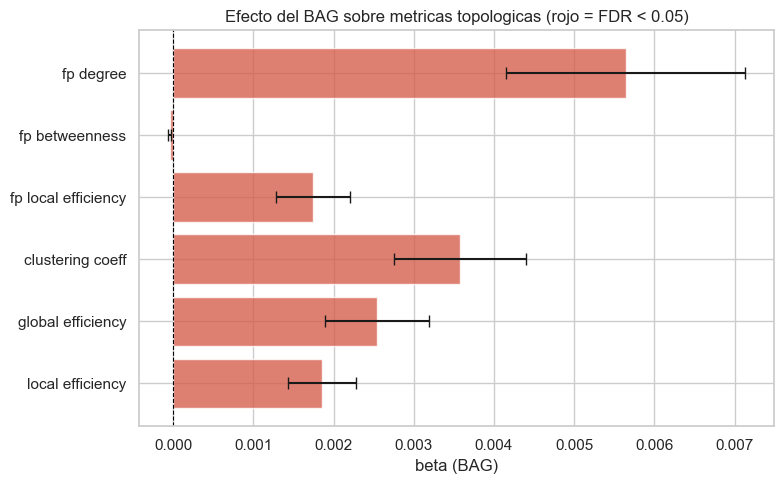

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(reg_df))
cols = ["#d6604d" if p<0.05 else "#aaaaaa" for p in reg_df["p_fdr"]]
ax.barh(ypos, reg_df["beta_BAG"],
        xerr=[reg_df["beta_BAG"]-reg_df["CI_low"], reg_df["CI_high"]-reg_df["beta_BAG"]],
        color=cols, alpha=0.8, capsize=4)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(ypos)
ax.set_yticklabels([m.replace("_"," ") for m in reg_df["metric"]])
ax.set_xlabel("beta (BAG)")
ax.set_title("Efecto del BAG sobre metricas topologicas (rojo = FDR < 0.05)")
plt.tight_layout()
plt.savefig("figs/03_regression_forest_plot.png", dpi=150)
plt.show()

## 9. Comparacion por diagnostico (CN vs AD vs FTD)

In [36]:
def _pg_val(r, *candidates):
    for c in candidates:
        if c in r.columns:
            return r[c].values[0]
    raise KeyError(f"Ninguna de {candidates} en {list(r.columns)}")

sub3 = df[df["diagnosis"].isin(["CN", "AD", "FTD"])].copy()

kw_rows = []
for m in TOPO:
    kw = pg.kruskal(data=sub3, dv=m, between="diagnosis")
    kw_rows.append({
        "metric": m,
        "H": _pg_val(kw, "H"),
        "p": _pg_val(kw, "p_unc", "p-unc"),
    })

kw_df = pd.DataFrame(kw_rows)
_, kw_df["p_fdr"], _, _ = multipletests(kw_df["p"], method="fdr_bh")
print(kw_df.round(4).to_string())

for m in kw_df.loc[kw_df["p_fdr"] < 0.05, "metric"]:
    ph = pg.pairwise_tests(
        data=sub3, dv=m, between="diagnosis",
        padjust="bonf", parametric=False,
    )
    cols = [c for c in ["A", "B", "U_val", "T", "p_corr", "p-corr"] if c in ph.columns]
    print(f"\nPost-hoc {m}:")
    print(ph[cols].round(4).to_string())

                metric        H       p   p_fdr
0     local_efficiency  13.2902  0.0013  0.0020
1    global_efficiency  12.2090  0.0022  0.0027
2     clustering_coeff  14.4315  0.0007  0.0020
3  fp_local_efficiency  13.8605  0.0010  0.0020
4       fp_betweenness   8.8577  0.0119  0.0119
5            fp_degree  18.2641  0.0001  0.0006

Post-hoc local_efficiency:
    A    B     U_val  p_corr
0  AD   CN  112593.0  0.0007
1  AD  FTD   65215.0  0.1515
2  CN  FTD   87940.0  0.9099

Post-hoc global_efficiency:
    A    B     U_val  p_corr
0  AD   CN  113244.0  0.0012
1  AD  FTD   67039.5  0.5282
2  CN  FTD   89710.5  0.3717

Post-hoc clustering_coeff:
    A    B     U_val  p_corr
0  AD   CN  111893.0  0.0004
1  AD  FTD   65013.0  0.1294
2  CN  FTD   88255.0  0.7882

Post-hoc fp_local_efficiency:
    A    B     U_val  p_corr
0  AD   CN  112204.0  0.0005
1  AD  FTD   65194.0  0.1491
2  CN  FTD   88148.0  0.8282

Post-hoc fp_betweenness:
    A    B     U_val  p_corr
0  AD   CN  143986.0  0.0081


## 10. Correlaciones parciales: topologia x MMSE

                metric         r         p    n     p_fdr
5            fp degree  0.097915  0.001987  997  0.011923
1    global efficiency  0.084784  0.007454  997  0.014040
0     local efficiency  0.082698  0.009059  997  0.014040
2     clustering coeff  0.082345  0.009360  997  0.014040
3  fp local efficiency  0.076632  0.015616  997  0.018739
4       fp betweenness -0.071120  0.024871  997  0.024871


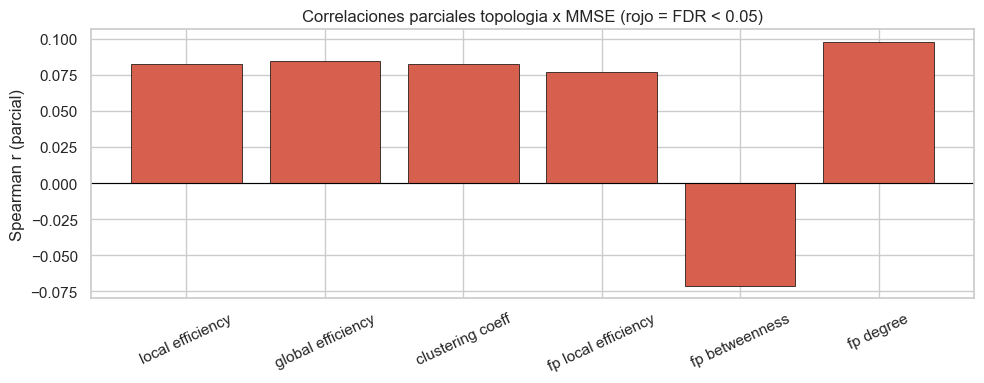

In [38]:
cross_rows = []
for m in TOPO:
    sub = df[[m, "mmse_total", "Age", "years_education"]].dropna()
    if len(sub) < 10:
        continue
    res = pg.partial_corr(
        data=sub, x=m, y="mmse_total",
        covar=["Age", "years_education"], method="spearman",
    )
    cross_rows.append({
        "metric": m.replace("_", " "),
        "r": _pg_val(res, "r"),
        "p": _pg_val(res, "p_val", "p-val"),
        "n": len(sub),
    })

cross_df = pd.DataFrame(cross_rows)
_, cross_df["p_fdr"], _, _ = multipletests(cross_df["p"], method="fdr_bh")
print(cross_df.sort_values("p").to_string())

fig, ax = plt.subplots(figsize=(10, 4))
cc = ["#d6604d" if p < 0.05 else "#aaaaaa" for p in cross_df["p_fdr"]]
ax.bar(cross_df["metric"], cross_df["r"], color=cc, edgecolor="black", lw=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Spearman r (parcial)")
ax.set_title("Correlaciones parciales topologia x MMSE (rojo = FDR < 0.05)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig("figs/03_topo_mmse_correlations.png", dpi=150)
plt.show()

## 11. Guardar resultados

In [39]:
df.to_csv("outputs/full_results_table.csv", index=False)
reg_df.to_csv("outputs/regression_results.csv", index=False)
cross_df.to_csv("outputs/topo_cognition_correlations.csv", index=False)
print("Guardado.")

Guardado.
